In [1]:
# Rahma Mohamed Abdo Mohamed Elsharkawy
# rahma.elsharkawy82005@gmail.com


In [7]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

In [9]:
def oracle(s):
    n = len(s)
    qr = QuantumRegister(n, 'q')
    a = QuantumRegister(1, 'a')  # output qubit
    circuit = QuantumCircuit(qr, a, name="Oracle")
    
    circuit.barrier()

    # For each bit in s, if it's '1', apply a CNOT from q[i] to a
    for i, bit in enumerate(s):
        if bit == '1':
            circuit.cx(qr[i], a[0])

    circuit.barrier()
    return circuit

In [17]:
from qiskit import QuantumCircuit

from qiskit.visualization import plot_histogram

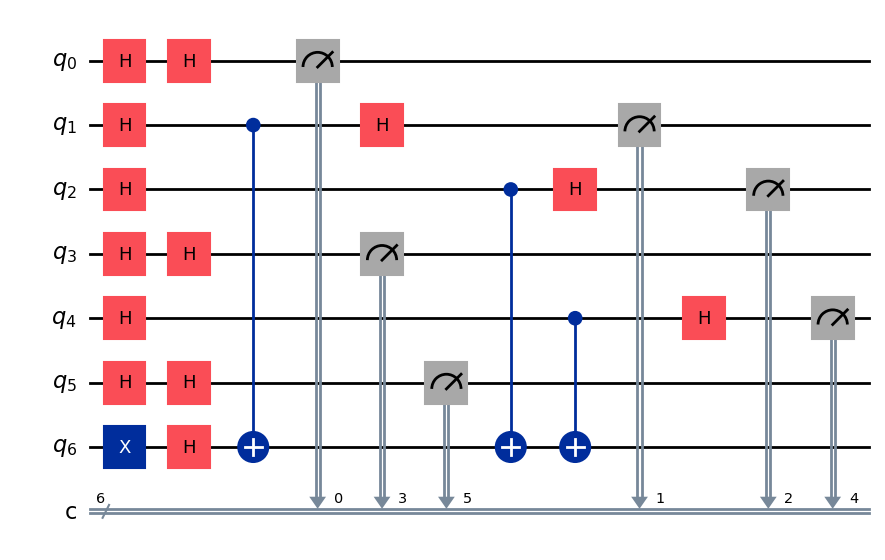

In [25]:
s = "011010"
n = len(s)

# Create quantum circuit with n input qubits, 1 output qubit, and n classical bits
qc = QuantumCircuit(n+1, n)

# Step 1: Initialize output qubit in |1> (apply X then H)
qc.x(n)          # flip |0> to |1>
qc.h(n)          # Hadamard to make |->

# Step 2: Apply Hadamard gates to all input qubits
for i in range(n):
    qc.h(i)

# Step 3: Oracle implementation (apply CNOT for each 1 in s)
for i, bit in enumerate(s):
    if bit == "1":
        qc.cx(i, n)

# Step 4: Apply Hadamards again to input qubits
for i in range(n):
    qc.h(i)

# Step 5: Measure input qubits
for i in range(n):
    qc.measure(i, i)

qc.draw("mpl")

In [23]:
from qiskit_aer import AerSimulator
sim = AerSimulator()
res = sim.run(qc, shots=1024).result()
print(res.get_counts())



{'010110': 1024}
